## setup

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import copy
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import random 
import copy
from scipy.signal import butter, sosfiltfilt

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [2]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [ ]:
batch_size = 32
num_epochs = 60
k = 9
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


In [4]:
def _frequency_mask(start_freq, bw, X):
    X = X.copy()

    stop_freq = start_freq + bw

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=250,
        output="sos"
    )

    return sosfiltfilt(sos, X, axis=-1)

In [5]:
freqs=[0,0,0]
nums=3
rng = np.random.default_rng(seed=42)

for i in range(nums):
    freqs[i]=rng.uniform(4, 32)
    

## both



================ BANDWIDTH 4 ================

========== FREQ 25.670769359566975, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.8759645061728395), 'fmeasure': 0.6495792791008921}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6684027777777778, 'auc': np.float64(0.8880730774176956), 'fmeasure': 0.6676568614683033}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8560635288065842), 'fmeasure': 0.6174515742198141}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8721225565843622), 'fmeasure': 0.6403116628623827}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.8770134066358025), 'fmeasure': 0.6487260123242435}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8659416795267489), 'fmeasure': 0.6491372096692583}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8

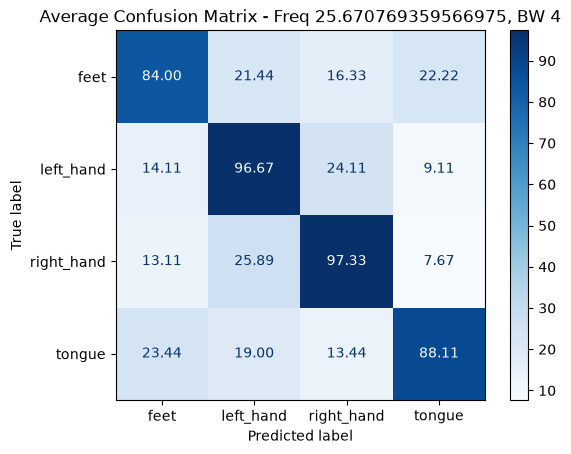


========== FREQ 16.288596313057464, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8621238425925926), 'fmeasure': 0.6337559871853198}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6614583333333334, 'auc': np.float64(0.8810241448045266), 'fmeasure': 0.6593362527438216}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.8452449845679012), 'fmeasure': 0.5856300136602504}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8737782921810701), 'fmeasure': 0.6364072400328806}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8732478137860081), 'fmeasure': 0.6200980936825224}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8644547325102881), 'fmeasure': 0.631731914622753}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8614486882716048), 'fmeasure': 0.6087192363677169}

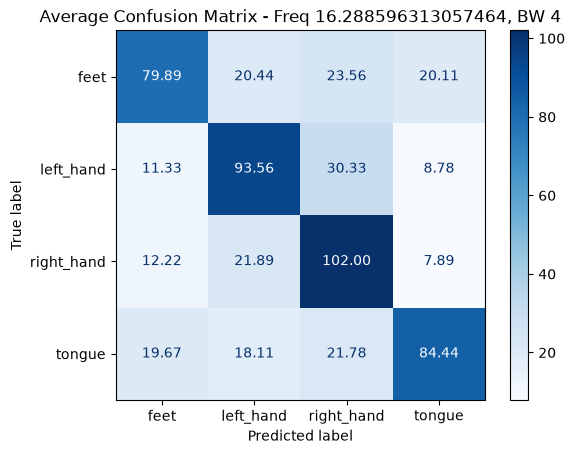


========== FREQ 28.04074175751871, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8646918402777778), 'fmeasure': 0.6225883885574682}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8829250257201647), 'fmeasure': 0.6482908063887807}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8576147762345679), 'fmeasure': 0.625271494521593}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8697313850308642), 'fmeasure': 0.6322066072027188}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.8728941615226337), 'fmeasure': 0.6479116300814071}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8680696212705762), 'fmeasure': 0.6236126897506781}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8628432034465021), 'fmeasure': 0.63040571

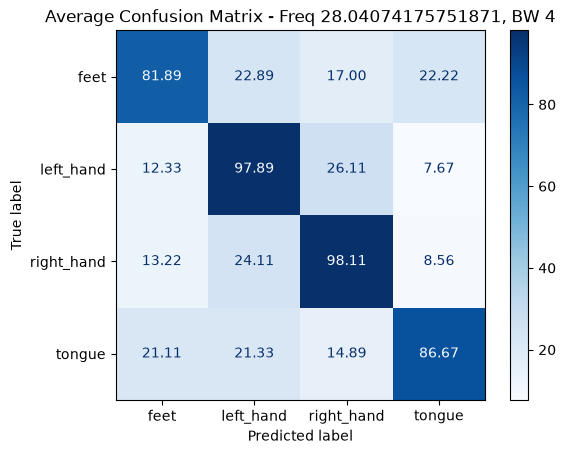


========== BANDWIDTH 4 ==========
acc: 0.6311 ± 0.0046
auc: 0.8663 ± 0.0017
fmeasure: 0.6303 ± 0.0049


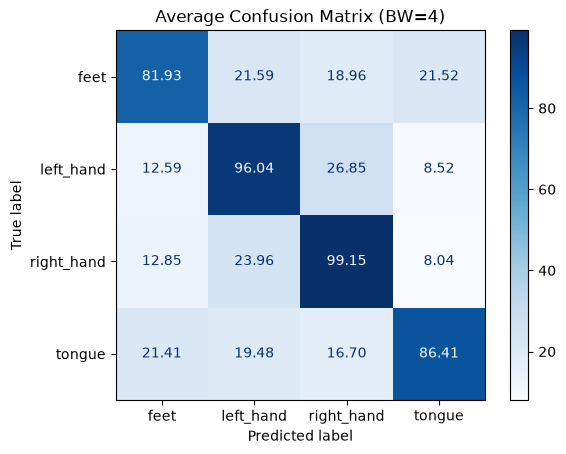



================ BANDWIDTH 6 ================

========== FREQ 25.670769359566975, BANDWIDTH 6 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8731794945987654), 'fmeasure': 0.630789350253218}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6631944444444444, 'auc': np.float64(0.8830054012345677), 'fmeasure': 0.6602086748196364}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8577514146090534), 'fmeasure': 0.5877107447532111}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8690562307098766), 'fmeasure': 0.629381620355062}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.872657053755144), 'fmeasure': 0.655088626721216}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8668659979423868), 'fmeasure': 0.6081052225306273}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.866926

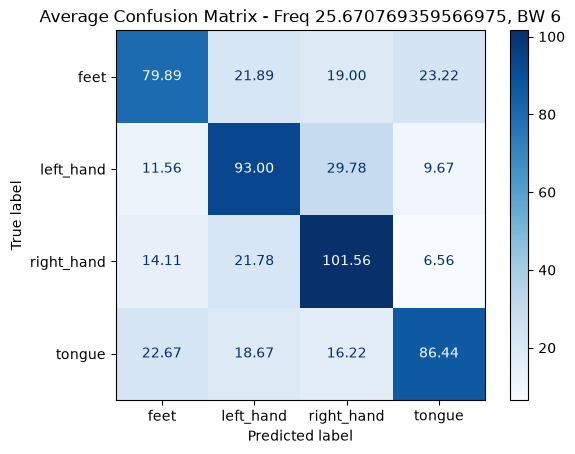


========== FREQ 16.288596313057464, BANDWIDTH 6 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8607454025205761), 'fmeasure': 0.6123142079307126}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8768285429526749), 'fmeasure': 0.6439731324585584}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8523943865740741), 'fmeasure': 0.6003135394422531}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.864671746399177), 'fmeasure': 0.6367947178871548}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8666369277263374), 'fmeasure': 0.6205148424702257}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.864085005144033), 'fmeasure': 0.6359261462805019}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5833333333333334, 'auc': np.float64(0.850951646090535), 'fmeasure': 0.580849107

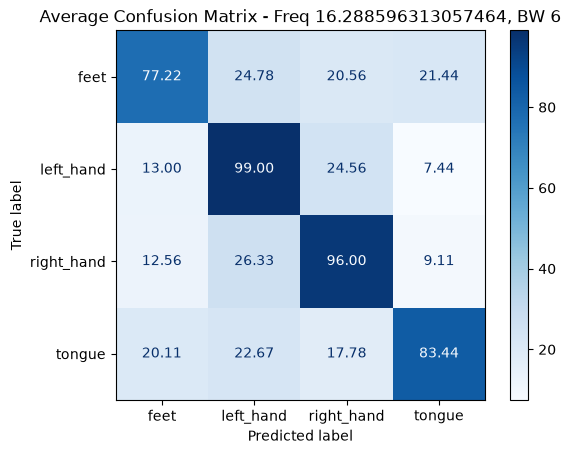


========== FREQ 28.04074175751871, BANDWIDTH 6 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.864527070473251), 'fmeasure': 0.6378226325374455}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.885963220164609), 'fmeasure': 0.6484917657587779}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8666208526234568), 'fmeasure': 0.6578222368296321}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8768325617283951), 'fmeasure': 0.646378996323447}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.879758230452675), 'fmeasure': 0.6272401207017484}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8768687307098765), 'fmeasure': 0.6299657255272526}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8662189750514403), 'fmeasure': 0.62103490555

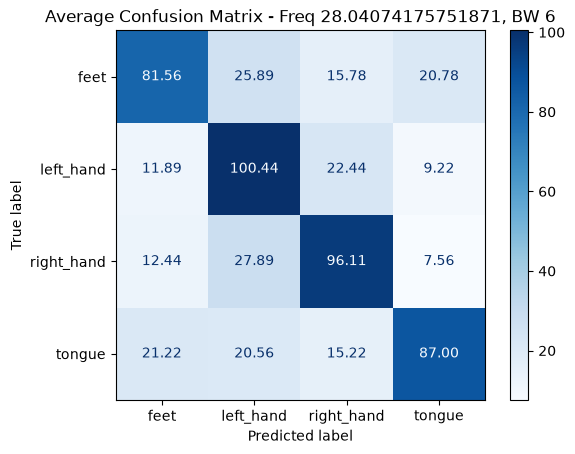


========== BANDWIDTH 6 ==========
acc: 0.6260 ± 0.0067
auc: 0.8660 ± 0.0043
fmeasure: 0.6248 ± 0.0070


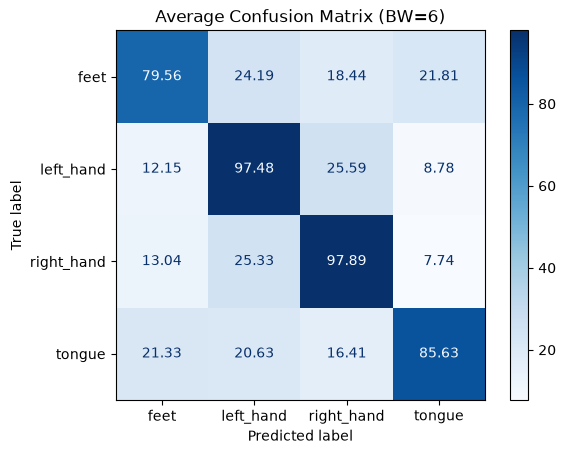



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8712987075617286), 'fmeasure': 0.6438847903195073}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8871889467592592), 'fmeasure': 0.6591362220963113}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8747910236625515), 'fmeasure': 0.6544353831864034}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8630119920267489), 'fmeasure': 0.6139840704401884}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8865298675411522), 'fmeasure': 0.6549292372085052}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8653830697016461), 'fmeasure': 0.6300546723561476}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.85

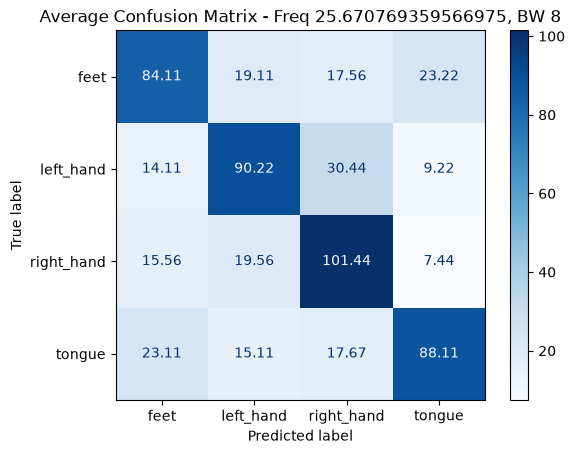


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8661948623971193), 'fmeasure': 0.6287760577915377}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8755264596193416), 'fmeasure': 0.6423397299074355}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.843283822016461), 'fmeasure': 0.5869808852439157}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8564935378086419), 'fmeasure': 0.6250187470856046}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.5815972222222222, 'auc': np.float64(0.8596080889917695), 'fmeasure': 0.5808696834550208}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8523099922839505), 'fmeasure': 0.6126469512278622}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.59375, 'auc': np.float64(0.8453012474279835), 'fmeasure': 0.5925301532848702}


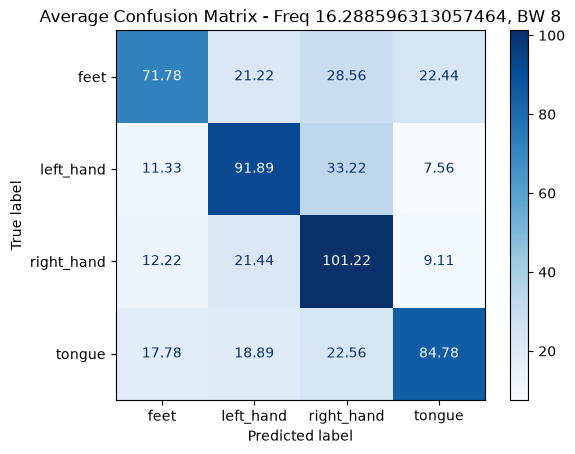


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6631944444444444, 'auc': np.float64(0.8786811985596709), 'fmeasure': 0.6622999141503656}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8817193930041151), 'fmeasure': 0.6538701944399421}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8722310635288064), 'fmeasure': 0.6294185362674741}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8721225565843621), 'fmeasure': 0.6466214096461802}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8774072466563786), 'fmeasure': 0.6566870850955948}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8642698688271606), 'fmeasure': 0.6124026798519575}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.8584667566872429), 'fmeasure': 0.6107797979268365}

Fold 8/9



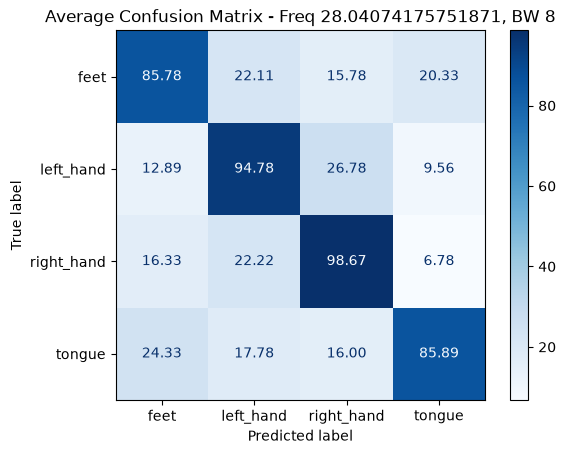


========== BANDWIDTH 8 ==========
acc: 0.6242 ± 0.0122
auc: 0.8640 ± 0.0073
fmeasure: 0.6234 ± 0.0124


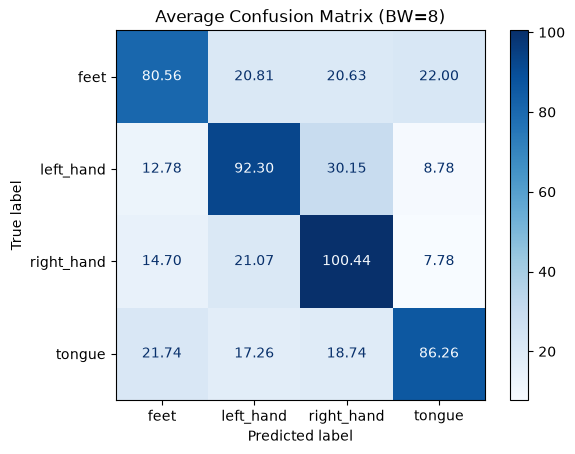

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_tr = _frequency_mask(freq, bw, X_tr).copy()
            X_va = _frequency_mask(freq, bw, X_va).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=64,
                F1=32,
                D=4,
                F2=16,
                dropoutRate=0.4854763234903182,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0004102432506048275
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm


## train



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========

Fold 1/9


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(



Fold 1 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8691928690843621), 'fmeasure': 0.6306954361578916}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6597222222222222, 'auc': np.float64(0.8872532471707819), 'fmeasure': 0.6571160186579063}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8655880272633745), 'fmeasure': 0.6430230117404678}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6423611111111112, 'auc': np.float64(0.8773750964506174), 'fmeasure': 0.6421300700126523}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8667534722222222), 'fmeasure': 0.6199129574563806}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8599135159465021), 'fmeasure': 0.6170325071960578}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8553280928497942), 'fmeasure': 0.6025603588998649}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.58506944444

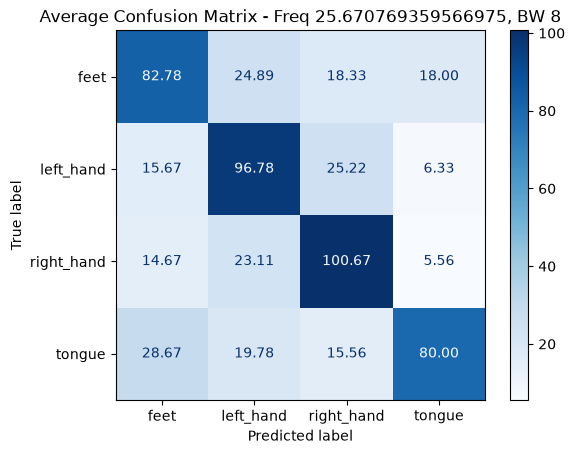


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========

Fold 1/9
Early stopping at epoch 59

Fold 1 Final Validation -
{'acc': 0.5572916666666666, 'auc': np.float64(0.8497098443930041), 'fmeasure': 0.5611486217582434}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8675451710390947), 'fmeasure': 0.6246502603213274}

Fold 3/9
Early stopping at epoch 42

Fold 3 Final Validation -
{'acc': 0.5607638888888888, 'auc': np.float64(0.83179012345679), 'fmeasure': 0.5599024608714974}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8567748521090536), 'fmeasure': 0.6023380329252498}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6006944444444444, 'auc': np.float64(0.8598733281893004), 'fmeasure': 0.6020159398444133}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8556013695987654), 'fmeasure': 0.608488937765223}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5850694444444444, 'auc': np.float64(0.8

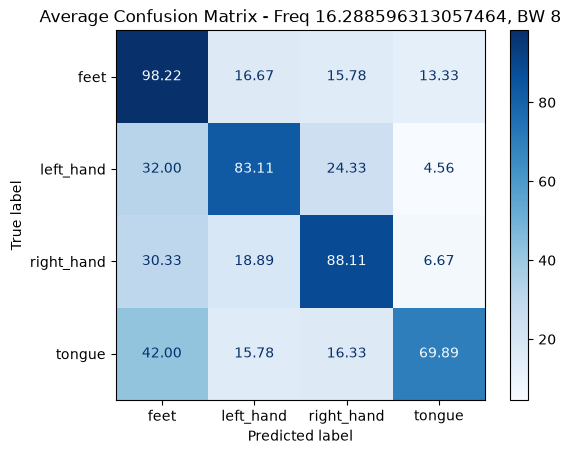


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8655076517489712), 'fmeasure': 0.6370146093417307}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6597222222222222, 'auc': np.float64(0.8811487268518517), 'fmeasure': 0.6600087621399713}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8645873521090536), 'fmeasure': 0.6159484851010185}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8616616833847738), 'fmeasure': 0.62391123374853}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8725525655864197), 'fmeasure': 0.6394224438073673}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8664922518004116), 'fmeasure': 0.6245566400230034}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8593348122427984), 'fmeasure': 0.5856623341056318}

Fol

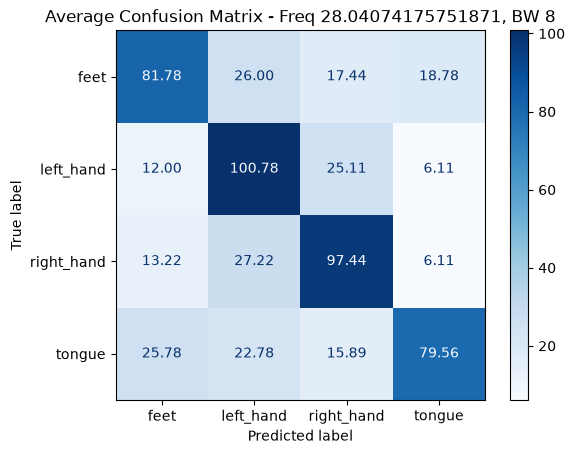


========== BANDWIDTH 8 ==========
acc: 0.6129 ± 0.0168
auc: 0.8601 ± 0.0068
fmeasure: 0.6122 ± 0.0164


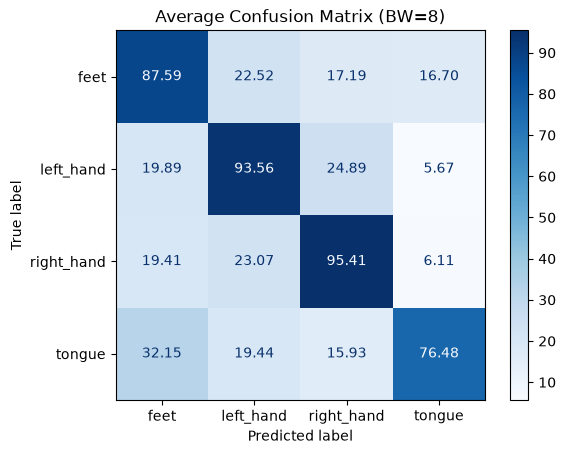

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_tr = _frequency_mask(freq, bw, X_tr).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=250,
                F1=8,
                D=1,
                F2=16,
                dropoutRate=0.25550867989537085,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0026353430928847833, 
                weight_decay=1.4077242503865625e-06
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm


## test



================ BANDWIDTH 4 ================

========== FREQ 25.670769359566975, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8691325874485597), 'fmeasure': 0.6446577786256344}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8799832818930039), 'fmeasure': 0.6190537873898064}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8627748842592592), 'fmeasure': 0.6103824287570998}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.862766846707819), 'fmeasure': 0.5928501862267063}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8749276620370371), 'fmeasure': 0.6143635832582632}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8734005272633745), 'fmeasure': 0.6349731185712871}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.fl

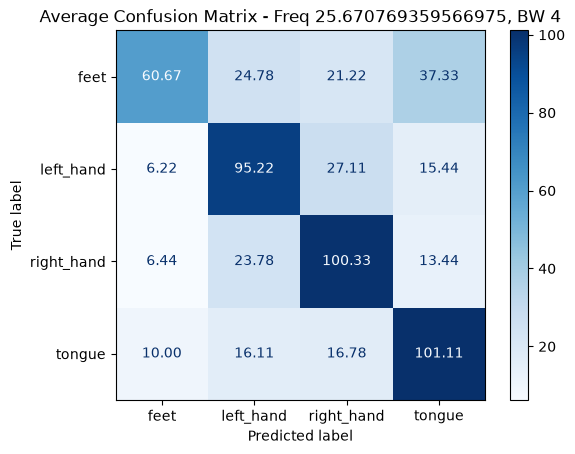


========== FREQ 16.288596313057464, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5798611111111112, 'auc': np.float64(0.8460768711419752), 'fmeasure': 0.5639291838869339}

Fold 2/9
Early stopping at epoch 29

Fold 2 Final Validation -
{'acc': 0.5555555555555556, 'auc': np.float64(0.8196775334362139), 'fmeasure': 0.5350996091379301}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5868055555555556, 'auc': np.float64(0.8482108410493826), 'fmeasure': 0.5754249755644802}

Fold 4/9
Early stopping at epoch 42

Fold 4 Final Validation -
{'acc': 0.5659722222222222, 'auc': np.float64(0.8303313078703703), 'fmeasure': 0.5435418766135045}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.578125, 'auc': np.float64(0.8633897569444445), 'fmeasure': 0.5634851665830358}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5694444444444444, 'auc': np.float64(0.8496495627572016), 'fmeasure': 0.5600463450771428}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5451388888888888, 'auc': np.float

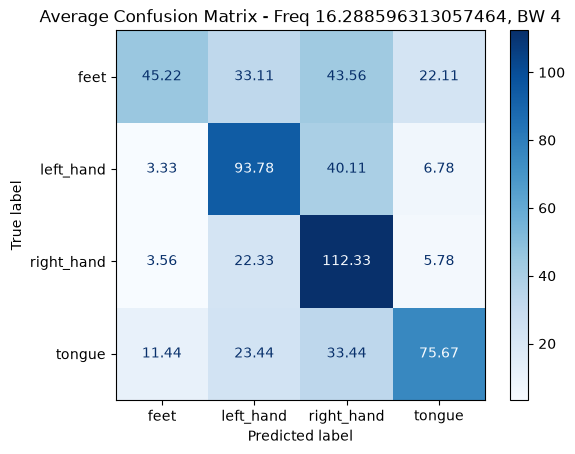


========== FREQ 28.04074175751871, BANDWIDTH 4 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6614583333333334, 'auc': np.float64(0.8761533886316871), 'fmeasure': 0.6601246019450185}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6614583333333334, 'auc': np.float64(0.8846571180555555), 'fmeasure': 0.6566243266701082}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8654875578703706), 'fmeasure': 0.6173090937751018}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8754822530864197), 'fmeasure': 0.6301150773769701}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.880859375), 'fmeasure': 0.6482463962142846}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8622805748456789), 'fmeasure': 0.6268916475631612}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8636268647119342), 'fmeasure': 0.62565340025473

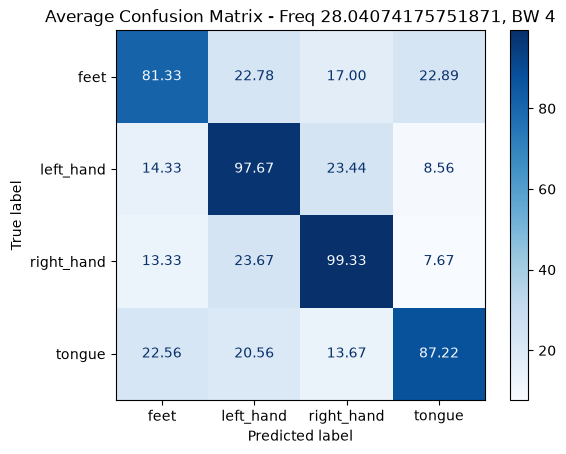


========== BANDWIDTH 4 ==========
acc: 0.6076 ± 0.0288
auc: 0.8590 ± 0.0122
fmeasure: 0.6004 ± 0.0333


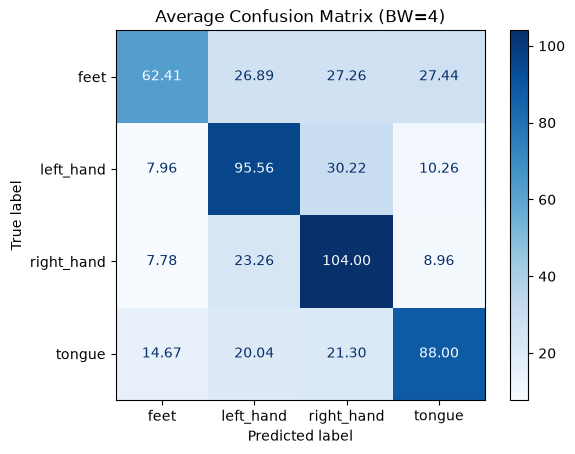



================ BANDWIDTH 6 ================

========== FREQ 25.670769359566975, BANDWIDTH 6 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8701855066872427), 'fmeasure': 0.6255128700336259}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8818359375000001), 'fmeasure': 0.618258221873516}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8575504758230453), 'fmeasure': 0.608721694336773}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8685619212962964), 'fmeasure': 0.6242003835045007}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8691607188786009), 'fmeasure': 0.6284039694685949}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8693616576646089), 'fmeasure': 0.6489677779299199}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.859

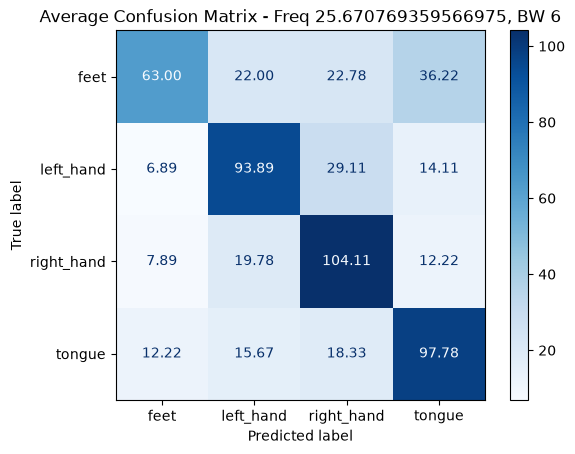


========== FREQ 16.288596313057464, BANDWIDTH 6 ==========

Fold 1/9
Early stopping at epoch 31

Fold 1 Final Validation -
{'acc': 0.5347222222222222, 'auc': np.float64(0.7979439943415638), 'fmeasure': 0.5122582572135355}

Fold 2/9
Early stopping at epoch 28

Fold 2 Final Validation -
{'acc': 0.5381944444444444, 'auc': np.float64(0.8190063978909464), 'fmeasure': 0.5016800233521482}

Fold 3/9
Early stopping at epoch 39

Fold 3 Final Validation -
{'acc': 0.5451388888888888, 'auc': np.float64(0.8105549125514403), 'fmeasure': 0.5287828610263104}

Fold 4/9
Early stopping at epoch 55

Fold 4 Final Validation -
{'acc': 0.5729166666666666, 'auc': np.float64(0.8464465985082305), 'fmeasure': 0.5578352220438045}

Fold 5/9
Early stopping at epoch 38

Fold 5 Final Validation -
{'acc': 0.5399305555555556, 'auc': np.float64(0.8325617283950617), 'fmeasure': 0.5161741590572766}

Fold 6/9
Early stopping at epoch 33

Fold 6 Final Validation -
{'acc': 0.5243055555555556, 'auc': np.float64(0.8150720164609

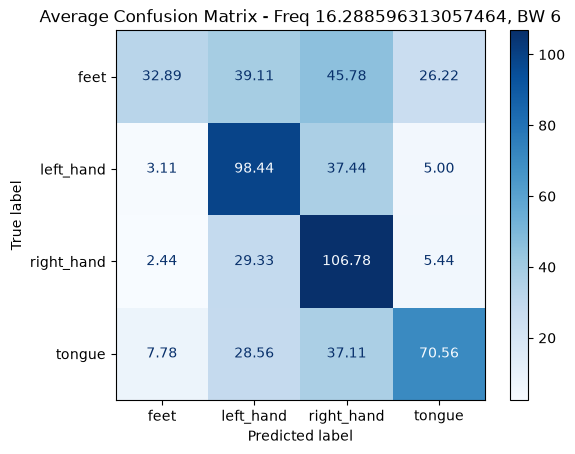


========== FREQ 28.04074175751871, BANDWIDTH 6 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8713710455246915), 'fmeasure': 0.6386045180440472}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8792639210390947), 'fmeasure': 0.6244584802401484}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.8730066872427983), 'fmeasure': 0.6493798663697725}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6649305555555556, 'auc': np.float64(0.8708405671296297), 'fmeasure': 0.6642418084406577}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6684027777777778, 'auc': np.float64(0.8889170203189298), 'fmeasure': 0.6644291986744305}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8757876800411523), 'fmeasure': 0.6367730347329357}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8659858860596708), 'fmeasure': 0.6147506612551481}

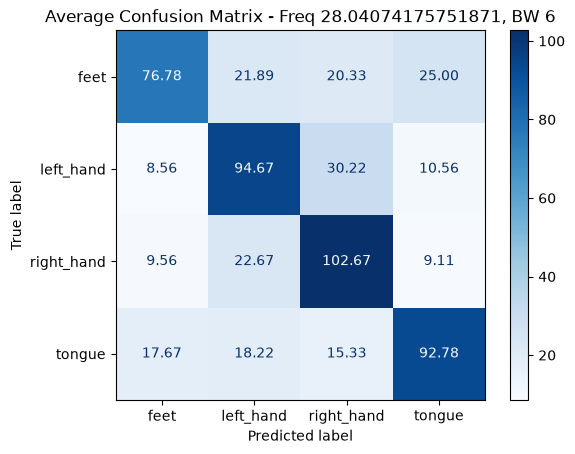


========== BANDWIDTH 6 ==========
acc: 0.5986 ± 0.0447
auc: 0.8504 ± 0.0250
fmeasure: 0.5887 ± 0.0528


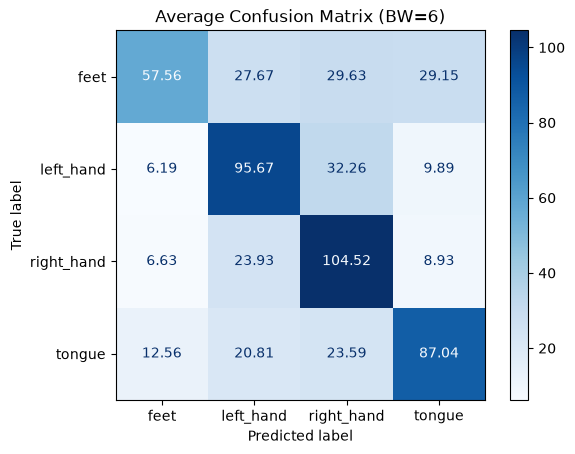



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8707360789609053), 'fmeasure': 0.638574929481746}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.888133359053498), 'fmeasure': 0.6281987580170201}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8593991126543209), 'fmeasure': 0.6097902847853565}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8623247813786007), 'fmeasure': 0.6142582393547041}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8774554719650206), 'fmeasure': 0.628963913727642}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8707843042695472), 'fmeasure': 0.6139787098827897}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.floa

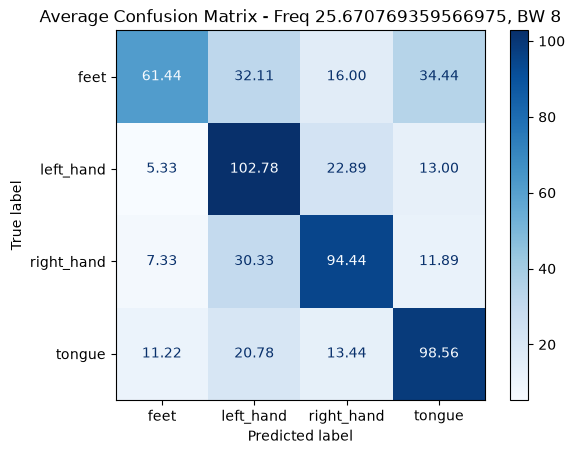


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========

Fold 1/9
Early stopping at epoch 32

Fold 1 Final Validation -
{'acc': 0.5138888888888888, 'auc': np.float64(0.7981168016975309), 'fmeasure': 0.4872750105947632}

Fold 2/9
Early stopping at epoch 46

Fold 2 Final Validation -
{'acc': 0.5538194444444444, 'auc': np.float64(0.8400326324588478), 'fmeasure': 0.5062903977530439}

Fold 3/9
Early stopping at epoch 45

Fold 3 Final Validation -
{'acc': 0.5173611111111112, 'auc': np.float64(0.8183714313271605), 'fmeasure': 0.4814361100546287}

Fold 4/9
Early stopping at epoch 26

Fold 4 Final Validation -
{'acc': 0.5104166666666666, 'auc': np.float64(0.7939694251543209), 'fmeasure': 0.4828942837656498}

Fold 5/9
Early stopping at epoch 58

Fold 5 Final Validation -
{'acc': 0.5555555555555556, 'auc': np.float64(0.8494687178497943), 'fmeasure': 0.5340433182972901}

Fold 6/9
Early stopping at epoch 33

Fold 6 Final Validation -
{'acc': 0.5520833333333334, 'auc': np.float64(0.8069540895061

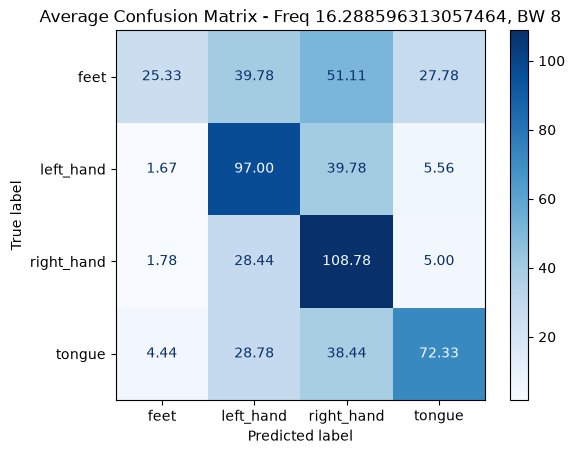


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.874634291409465), 'fmeasure': 0.6429998848265868}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8785927854938272), 'fmeasure': 0.6397171161196242}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8589007844650206), 'fmeasure': 0.6148825710194399}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8654915766460906), 'fmeasure': 0.6179505493999169}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8749156057098766), 'fmeasure': 0.641825326926079}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8696871784979422), 'fmeasure': 0.6322397011304206}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6423611111111112, 'auc': np.float64(0.8691808127572017), 'fmeasure': 0.6426062399989139}

Fol

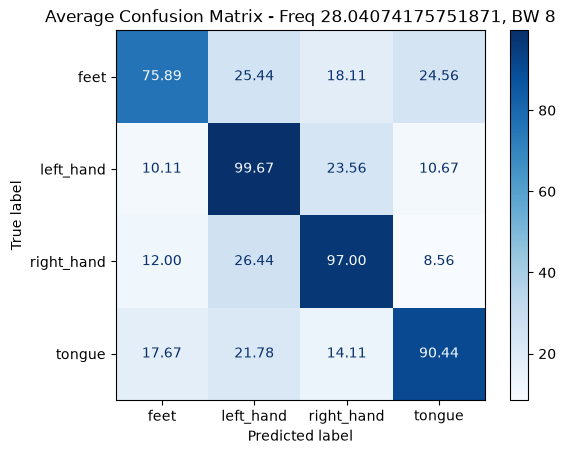


========== BANDWIDTH 8 ==========
acc: 0.5924 ± 0.0466
auc: 0.8490 ± 0.0261
fmeasure: 0.5804 ± 0.0587


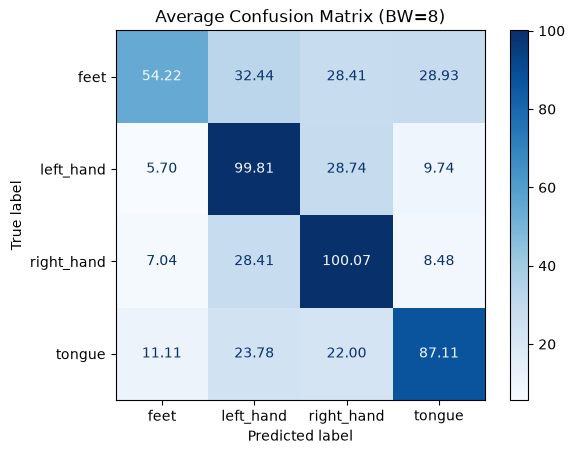

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_va = _frequency_mask(freq, bw, X_va).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=64,
                F1=32,
                D=4,
                F2=16,
                dropoutRate=0.4854763234903182,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0004102432506048275
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm
